<a href="https://colab.research.google.com/github/rubrael/zee_methodology_v1/blob/main/Ferramenta_Raspagem_T1kT0k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Passo 1: Faça a busca no TikTok e exporte o arquivo pelo Zeeschuimer.

Passo 2: Renomeie o arquivo para dados.ndjson

Passo 3: Arraste o arquivo para a pasta aqui na lateral esquerda.

Passo 4: Clique no botão de "Play" abaixo para gerar a planilha e os gráficos.

In [ ]:
# @title ▶️ Executar Raspagem de Dados
import pandas as pd
import json
import pytz
from pathlib import Path # Import Path for robust path handling

# 1. Dicionário mapeando os arquivos
# AUTOMATED: Detect all .ndjson files in /content folder
# arquivos_busca = {
#     '5amClub.ndjson': '5amClub',
#     'MarketingDigital.ndjson': 'MarketingDigital',
#     'RotinaProdutiva.ndjson': 'RotinaProdutiva',
#     'cortesdepodcast.ndjson': 'cortesdepodcast'
# }

lista_dfs = []
fuso_br = pytz.timezone('America/Sao_Paulo')

print("Iniciando extração avançada de dados e mapeamento de redes...\n")

# Dynamically find all .ndjson files in the /content directory
ndjson_files = list(Path("/content").glob("*.ndjson"))

if not ndjson_files:
    print("ALERTA: Nenhum arquivo .ndjson encontrado na pasta /content.")
else:
    for full_file_path in ndjson_files:
        arquivo = full_file_path.name
        # Use the filename (without extension) as the search term
        termo_busca = full_file_path.stem.replace('_', ' ').title()

        try:
            # Lê o arquivo bruto
            with open(full_file_path, 'r', encoding='utf-8') as f:
                dados_json = [json.loads(linha) for linha in f]

            # Achata a estrutura do JSON
            df = pd.json_normalize(dados_json)

            # Adicionamos a chave 'id' (ID do vídeo) para podermos montar a URL do post
            colunas_desejadas = {
                'data.id': 'Video_ID',
                'data.author.uniqueId': 'Autor',
                'data.desc': 'Descricao',
                'data.createTime': 'Unix_Time',
                'data.stats.playCount': 'Views',
                'data.stats.diggCount': 'Curtidas',
                'data.stats.commentCount': 'Comentarios',
                'data.stats.shareCount': 'Compartilhamentos',
                'data.music.title': 'Audio_Original'
            }

            # Filtra e renomeia
            df_filtrado = df[[col for col in colunas_desejadas.keys() if col in df.columns]].copy()
            df_filtrado.rename(columns=colunas_desejadas, inplace=True)
            df_filtrado['Termo_de_Busca'] = termo_busca

            # ==========================================
            # AS NOVAS COLUNAS COMEÇAM AQUI
            # ==========================================

            # 1. Montagem do Link do Post
            # A URL do TikTok sempre segue a lógica: tiktok.com/@autor/video/id_do_video
            if 'Autor' in df_filtrado.columns and 'Video_ID' in df_filtrado.columns:
                df_filtrado['Link_do_Post'] = 'https://www.tiktok.com/@' + df_filtrado['Autor'] + '/video/' + df_filtrado['Video_ID'].astype(str)

            # 2. Extração de Hashtags
            # Usa regex para encontrar todas as palavras que começam com # e as junta com vírgula
            if 'Descricao' in df_filtrado.columns:
                df_filtrado['Hashtags'] = df_filtrado['Descricao'].str.findall(r'#[À-ÿ\w]+').str.join(', ')

            # 3. Extração de Menções
            # Usa regex para encontrar todas as palavras que começam com @ e as junta com vírgula
            if 'Descricao' in df_filtrado.columns:
                df_filtrado['Mencoes'] = df_filtrado['Descricao'].str.findall(r'@[À-ÿ\w.]+').str.join(', ')

            # ==========================================

            # Conversão de Data e Hora
            if 'Unix_Time' in df_filtrado.columns:
                df_filtrado['Data_Hora'] = pd.to_datetime(df_filtrado['Unix_Time'], unit='s', utc=True)
                df_filtrado['Data_Hora'] = df_filtrado['Data_Hora'].dt.tz_convert(fuso_br).dt.strftime('%d/%m/%Y %H:%M')
                df_filtrado.drop(columns=['Unix_Time'], inplace=True)

            # Cálculo das Métricas de Mobilização
            # Convertendo as colunas para numérico antes da operação
            for col in ['Views', 'Curtidas', 'Comentarios', 'Compartilhamentos']:
                df_filtrado[col] = pd.to_numeric(df_filtrado[col], errors='coerce').fillna(0)

            df_filtrado['Views'] = df_filtrado['Views'].replace(0, 1) # Evita dividir por zero, substituindo 0 views por 1 para o cálculo
            df_filtrado['Taxa_Engajamento_Total (%)'] = ((df_filtrado['Curtidas'] + df_filtrado['Comentarios'] + df_filtrado['Compartilhamentos']) / df_filtrado['Views']) * 100
            df_filtrado['Taxa_Mobilizacao_Ativa (%)'] = ((df_filtrado['Comentarios'] + df_filtrado['Compartilhamentos']) / df_filtrado['Views']) * 100

            # Limpeza final: removemos a coluna Video_ID que estava solta, pois ela já está dentro do Link
            if 'Video_ID' in df_filtrado.columns:
                df_filtrado.drop(columns=['Video_ID'], inplace=True)

            # Adiciona o dataframe processado à nossa lista
            lista_dfs.append(df_filtrado)
            print(f"Sucesso: {arquivo} processado com Links, Tags e Menções. ({len(df_filtrado)} vídeos)")

        except FileNotFoundError:
            print(f"ALERTA: O arquivo '{full_file_path}' não foi encontrado no Colab. Pulando...")

# Junta todos os dados e exporta
if lista_dfs:
    df_final = pd.concat(lista_dfs, ignore_index=True)

    # Reordenando as colunas para que as novas informações fiquem bem visíveis na planilha
    ordem_colunas = [
        'Termo_de_Busca', 'Autor', 'Data_Hora', 'Link_do_Post', 'Hashtags', 'Mencoes',
        'Descricao', 'Views', 'Curtidas', 'Comentarios', 'Compartilhamentos',
        'Taxa_Engajamento_Total (%)', 'Taxa_Mobilizacao_Ativa (%)', 'Audio_Original'
    ]
    # Garante que só reordene as colunas que realmente existem no df_final
    ordem_colunas = [col for col in ordem_colunas if col in df_final.columns]
    df_final = df_final[ordem_colunas]

    nome_saida = 'Mapeamento_Completo_Redes.xlsx'
    df_final.to_excel(nome_saida, index=False)
    print(f"\nFinalizado! Planilha enriquecida salva como: {nome_saida}")

    # Mostra uma amostra das primeiras linhas na tela
    display(df_final.head())
else:
    print("\nNenhum dado foi processado. Verifique os arquivos.")

Iniciando extração avançada de dados e mapeamento de redes...

Sucesso: revitalizaçãourbana.ndjson processado com Links, Tags e Menções. (106 vídeos)
Sucesso: gentrificação.ndjson processado com Links, Tags e Menções. (105 vídeos)
Sucesso: 5amClub.ndjson processado com Links, Tags e Menções. (142 vídeos)
Sucesso: escala6x1.ndjson processado com Links, Tags e Menções. (139 vídeos)

Finalizado! Planilha enriquecida salva como: Mapeamento_Completo_Redes.xlsx


,Termo_de_Busca,Autor,Data_Hora,Link_do_Post,Hashtags,Mencoes,Descricao,Views,Curtidas,Comentarios,Compartilhamentos,Taxa_Engajamento_Total (%),Taxa_Mobilizacao_Ativa (%),Audio_Original
0,Revitalizaçãourbana,siberia.almeida,06/11/2025 00:14,https://www.tiktok.com/@siberia.almeida/video/...,"#CidadeGlobal, #saopaulocentro, #vemparaocentr...",,Quem mais acredita no potencial do projeto? #...,1447,57,2,0,4.077402,0.138217,som original
1,Revitalizaçãourbana,entrealtasebaixas,31/07/2026 09:38,https://www.tiktok.com/@entrealtasebaixas/vide...,,,Curitiba iniciou a retirada da fiação aérea em...,5193,298,2,11,5.988831,0.250337,som original - Andrei Cousseau
2,Revitalizaçãourbana,alexxjoes_,01/09/2026 19:57,https://www.tiktok.com/@alexxjoes_/video/76807...,"#JaboatãoDosGuararapes, #CajueiroSeco, #Revita...",,Um prédio que nunca cumpriu sua função origina...,10600,350,51,40,4.160377,0.858491,som original
3,Revitalizaçãourbana,ocoringafld,15/08/2026 15:45,https://www.tiktok.com/@ocoringafld/video/7674...,"#centro, #saopaulo, #vida, #segurancapublica",,SÃO PAULO #centro #saopaulo #vida #segurancapu...,1806,53,1,21,4.152824,1.218162,som original
4,Revitalizaçãourbana,eediycrafts,28/01/2026 00:03,https://www.tiktok.com/@eediycrafts/video/7600...,"#UrbanTransformation, #AIUrbanDesign, #CityRen...",,From Dehli 🇮🇳slums to an amazing urban transf...,38200,808,22,76,2.371728,0.256545,sonido original


Sucesso! Os 8 gráficos foram gerados e salvos como 'Painel_Views_vs_Engajamento.png'.


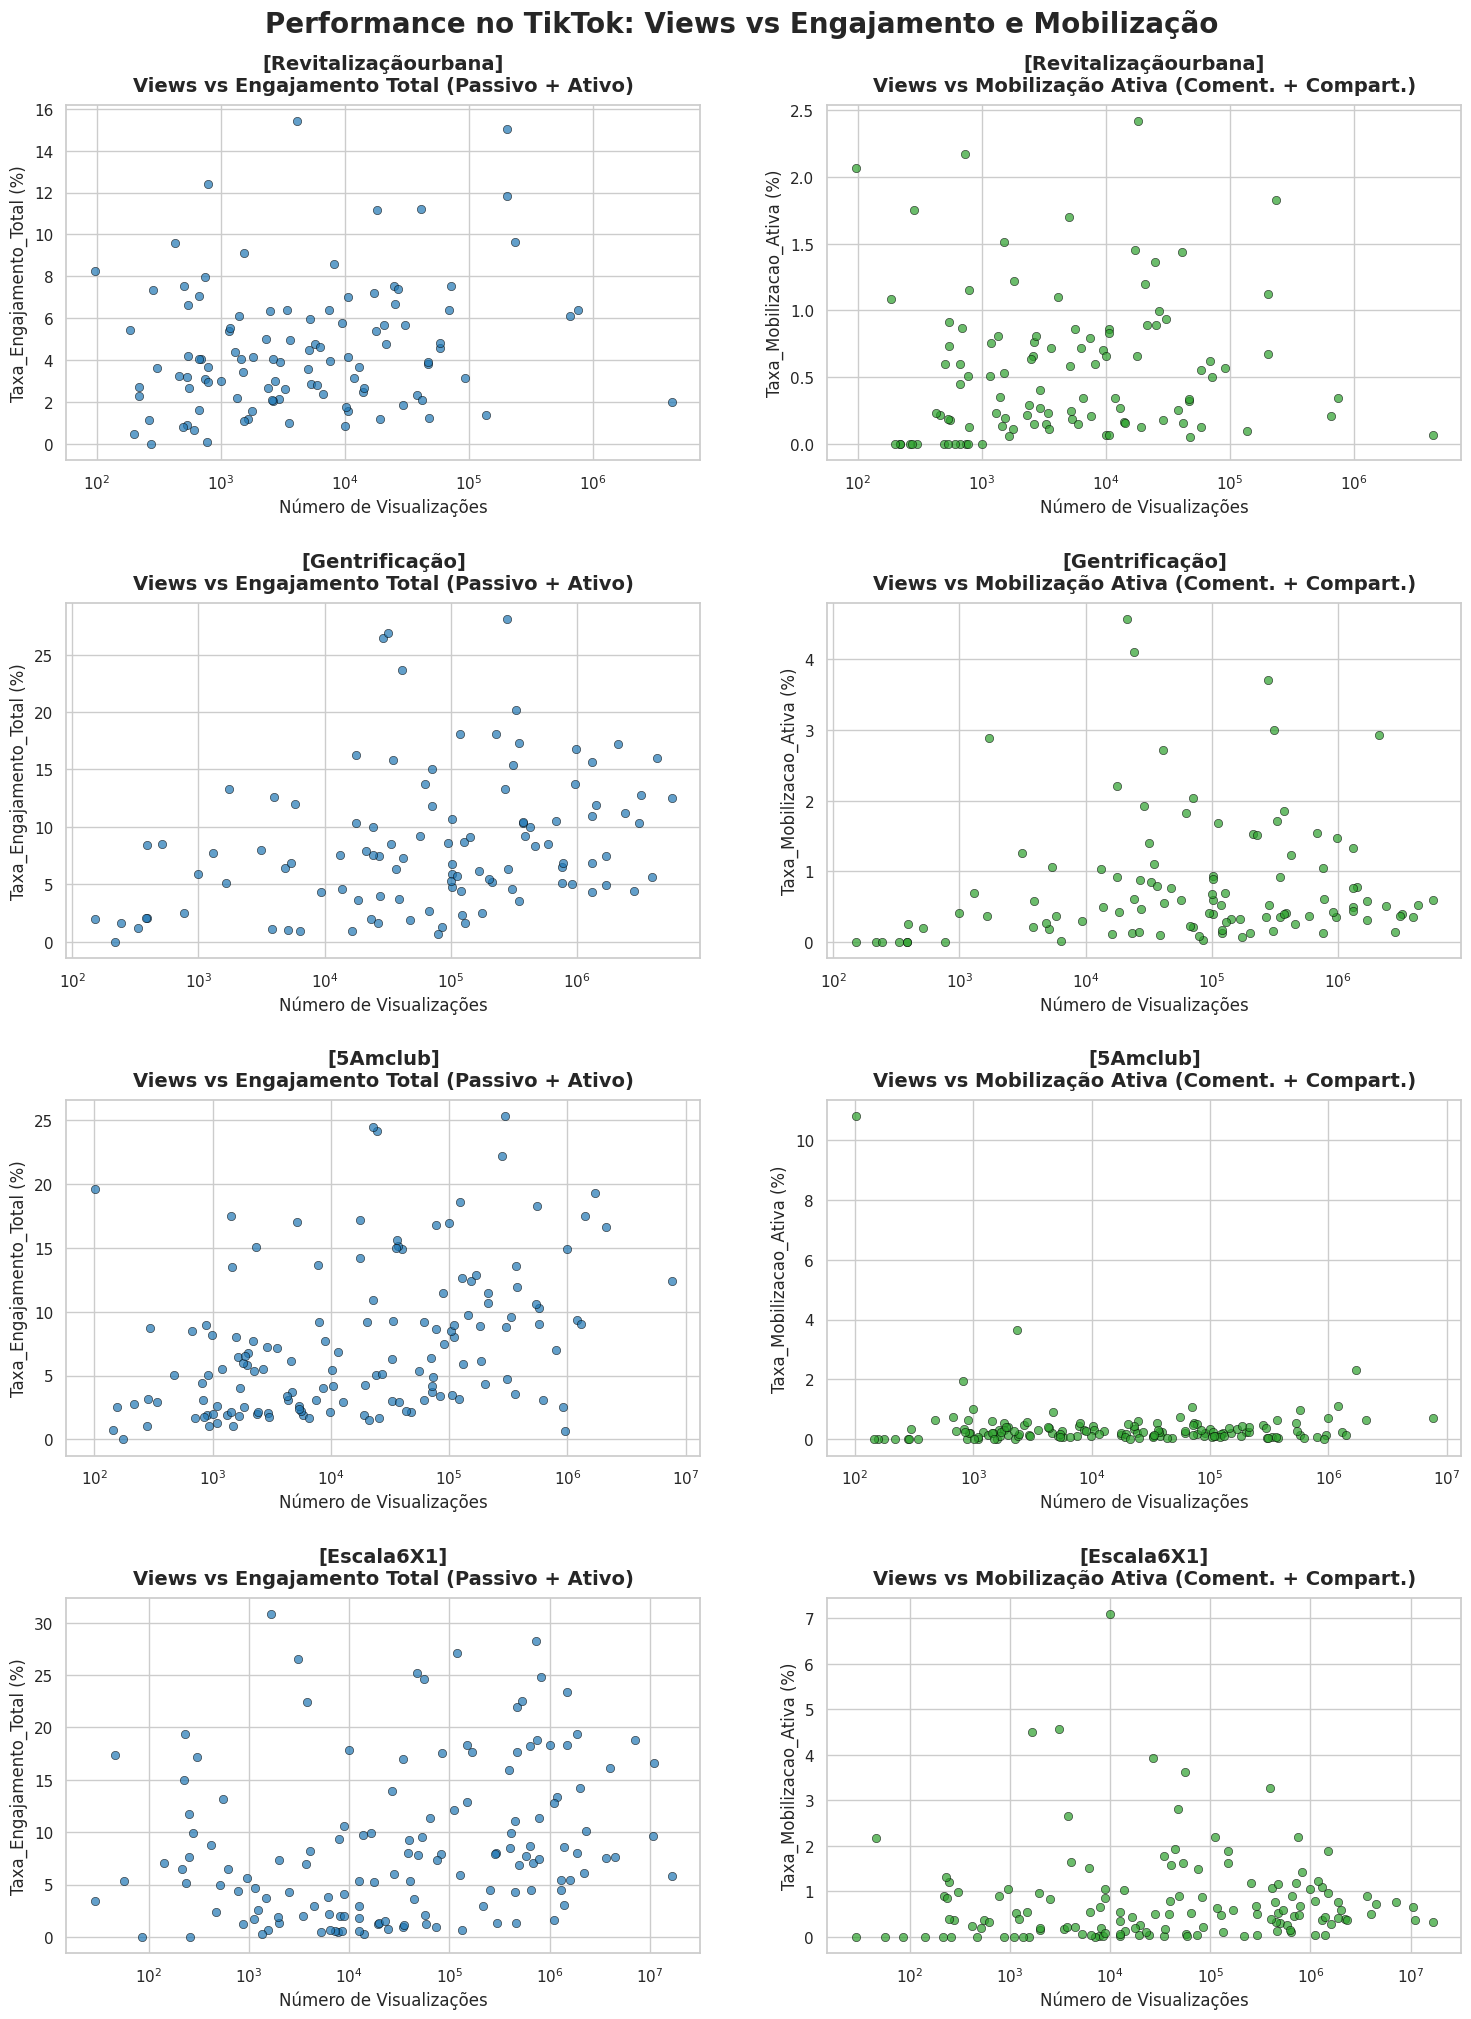

In [ ]:
# @title ▶️ Gerar Mapeamento de Dados (Views x Taxa de Engajamento)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de estilo para os gráficos ficarem com visual acadêmico e limpo
sns.set_theme(style="whitegrid")

# 2. Definimos as duas métricas que vão para o Eixo Y e os termos de busca
metricas_y = ['Taxa_Engajamento_Total (%)', 'Taxa_Mobilizacao_Ativa (%)']
# Dynamically get the search terms from the df_final DataFrame
termos = df_final['Termo_de_Busca'].unique().tolist()

# 3. Criação do "Painel" (Figura com número de linhas dinâmico baseado nos termos)
fig, axes = plt.subplots(nrows=len(termos), ncols=2, figsize=(18, 6 * len(termos)))
fig.suptitle('Performance no TikTok: Views vs Engajamento e Mobilização', fontsize=20, fontweight='bold', y=0.92)

# Adjust axes if there's only one row of plots (e.g., one search term)
if len(termos) == 1:
    axes = axes.reshape(1, -1) # Ensure axes is always a 2D array for consistent indexing

# 4. Loop que vai gerar os gráficos automaticamente
for i, termo in enumerate(termos):
    # Filtra os dados para pegar apenas os vídeos do termo atual da linha
    df_termo = df_final[df_final['Termo_de_Busca'] == termo]

    for j, metrica in enumerate(metricas_y):
        ax = axes[i, j] # Seleciona o "quadradinho" correto no painel

        # Se não houver dados para o termo, pula o gráfico para não dar erro
        if df_termo.empty:
            ax.text(0.5, 0.5, 'Sem dados para este termo', ha='center', va='center', fontsize=12, color='gray')
            ax.set_title(f'{termo} - {metrica}')
            ax.set_xlabel('Número de Visualizações', fontsize=12)
            ax.set_ylabel(metrica, fontsize=12)
            ax.set_xscale('log')
            continue

        # Cria o gráfico de dispersão (Scatter Plot)
        # O tamanho das bolhas (size) também reflete as Curtidas para dar mais dimensão
        sns.scatterplot(
            data=df_termo,
            x='Views',
            y=metrica,
            ax=ax,
            color='#2ca02c' if 'Ativa' in metrica else '#1f77b4', # Verde para mobilização, Azul para total
            alpha=0.7, # Deixa as bolhas levemente transparentes
            edgecolor='black'
        )

        # Formatação de títulos e eixos
        titulo_metrica = "Engajamento Total (Passivo + Ativo)" if "Total" in metrica else "Mobilização Ativa (Coment. + Compart.)"
        ax.set_title(f'[{termo}]\nViews vs {titulo_metrica}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Número de Visualizações', fontsize=12)
        ax.set_ylabel(metrica, fontsize=12)

        # Como as Views no TikTok variam do zero aos milhões, colocar o eixo X em escala Logarítmica
        # ajuda a não deixar todos os pontos espremidos no canto esquerdo da tela.
        ax.set_xscale('log')

# 5. Ajusta os espaços entre os gráficos para não encavalar os textos
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# 6. Salva o painel completo em alta resolução ANTES de exibir (para não sair em branco!)
nome_imagem = 'Painel_Views_vs_Engajamento.png'
plt.savefig(nome_imagem, dpi=300, bbox_inches='tight')

print(f"Sucesso! Os {len(termos) * 2} gráficos foram gerados e salvos como '{nome_imagem}'.")
plt.show()

Sucesso! O painel comparativo foi gerado e salvo como 'Comparacao_Agrupada_Termos.png'.


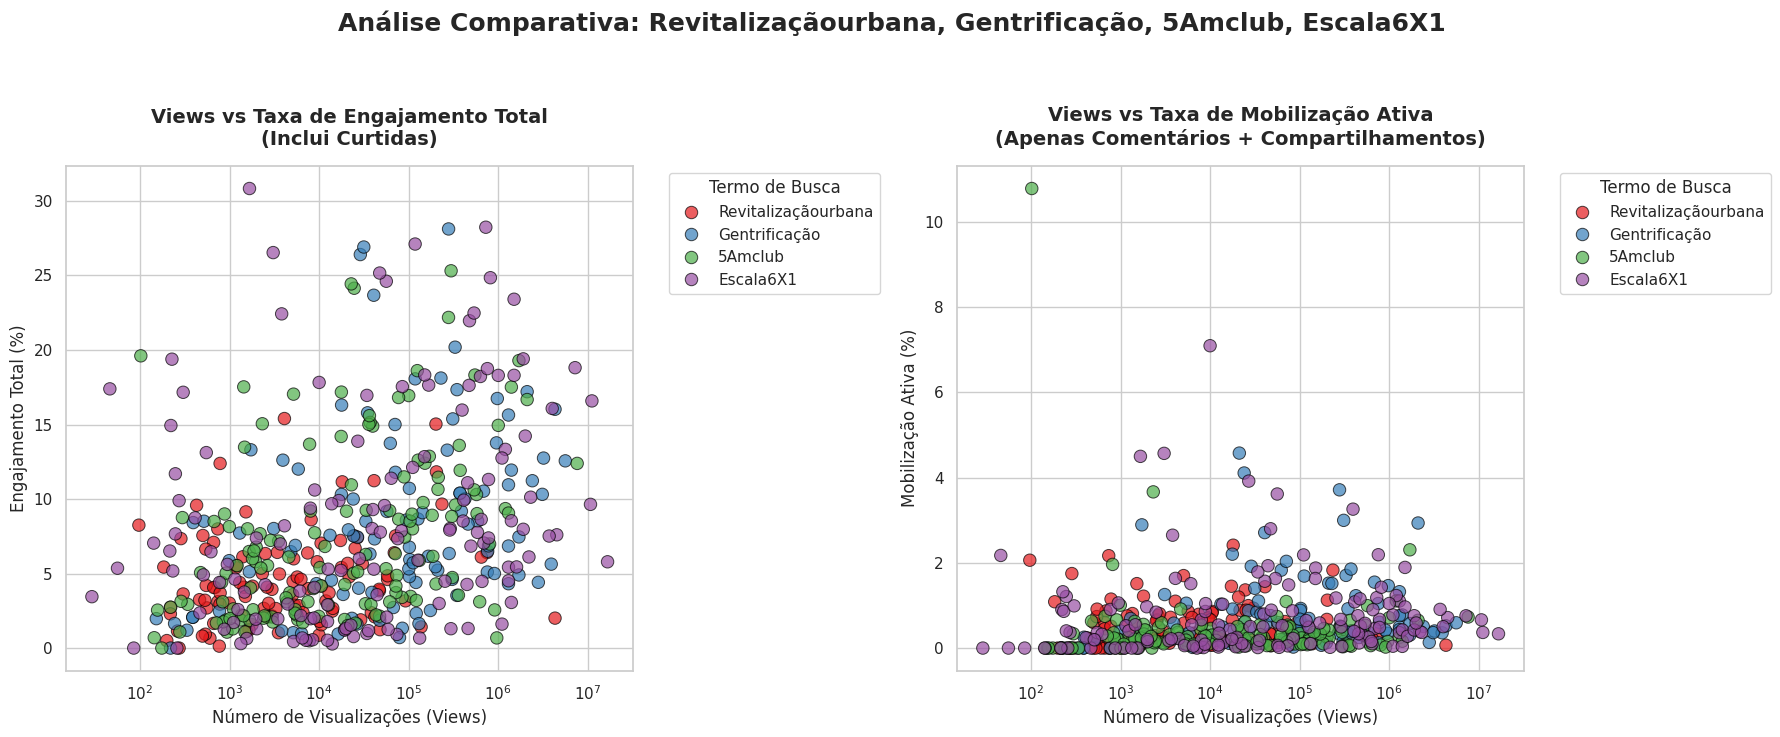

In [ ]:
# @title ▶️ Mapeamento Comparativo (Views x Taxa de Engajamentos)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to read the excel file

# Load df_final from the Excel file if it's not already defined
if 'df_final' not in locals():
    try:
        df_final = pd.read_excel('Mapeamento_Completo_Redes.xlsx')
        print("df_final loaded from 'Mapeamento_Completo_Redes.xlsx'.")
    except FileNotFoundError:
        print("Error: 'Mapeamento_Completo_Redes.xlsx' not found. Please ensure the previous cell was run.")
        # Exit to prevent further errors if file is truly missing
        raise

# 1. Configuração do estilo visual do gráfico (fundo branco com linhas guias)
sns.set_theme(style="whitegrid")

# 2. Cria a figura com 1 linha e 2 colunas para colocar os gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Dynamically get the search terms for the title
termos_str = ', '.join(df_final['Termo_de_Busca'].unique().tolist())
# Título geral do painel
fig.suptitle(f'Análise Comparativa: {termos_str}', fontsize=18, fontweight='bold', y=1.05)

# Definimos uma paleta de cores forte e contrastante para distinguir bem os termos
paleta_cores = "Set1"

# --- GRÁFICO 1: Engajamento Total (Painel da Esquerda) ---
sns.scatterplot(
    data=df_final,
    x='Views',
    y='Taxa_Engajamento_Total (%)',
    hue='Termo_de_Busca',
    palette=paleta_cores,
    alpha=0.7, # Transparência para ver quando os pontos se sobrepõem
    edgecolor='black',
    s=80, # Tamanho das bolhas
    ax=axes[0]
)
axes[0].set_title('Views vs Taxa de Engajamento Total\n(Inclui Curtidas)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Número de Visualizações (Views)', fontsize=12)
axes[0].set_ylabel('Engajamento Total (%)', fontsize=12)
axes[0].set_xscale('log') # Escala logarítmica obrigatória para lidar com a variação do TikTok

# --- GRÁFICO 2: Mobilização Ativa (Painel da Direita) ---
sns.scatterplot(
    data=df_final,
    x='Views',
    y='Taxa_Mobilizacao_Ativa (%)',
    hue='Termo_de_Busca',
    palette=paleta_cores,
    alpha=0.7,
    edgecolor='black',
    s=80,
    ax=axes[1]
)
axes[1].set_title('Views vs Taxa de Mobilização Ativa\n(Apenas Comentários + Compartilhamentos)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Número de Visualizações (Views)', fontsize=12)
axes[1].set_ylabel('Mobilização Ativa (%)', fontsize=12)
axes[1].set_xscale('log')

# 3. Ajuste fino das legendas
# Movemos a legenda para o lado de fora do gráfico para que ela não cubra nenhuma bolha de dados importante
axes[0].legend(title='Termo de Busca', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].legend(title='Termo de Busca', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Ajusta os espaços entre os gráficos para os textos não baterem uns nos outros
plt.tight_layout()

# 5. Salvamento rigoroso da imagem em alta resolução ANTES de exibir na tela
nome_grafico = 'Comparacao_Agrupada_Termos.png'
plt.savefig(nome_grafico, dpi=300, bbox_inches='tight')

print(f"Sucesso! O painel comparativo foi gerado e salvo como '{nome_grafico}'.")

# 6. Exibe a imagem no Colab
plt.show()

✅ Gráfico de barras salvo como: Media_Engajamento_Por_Termo.png


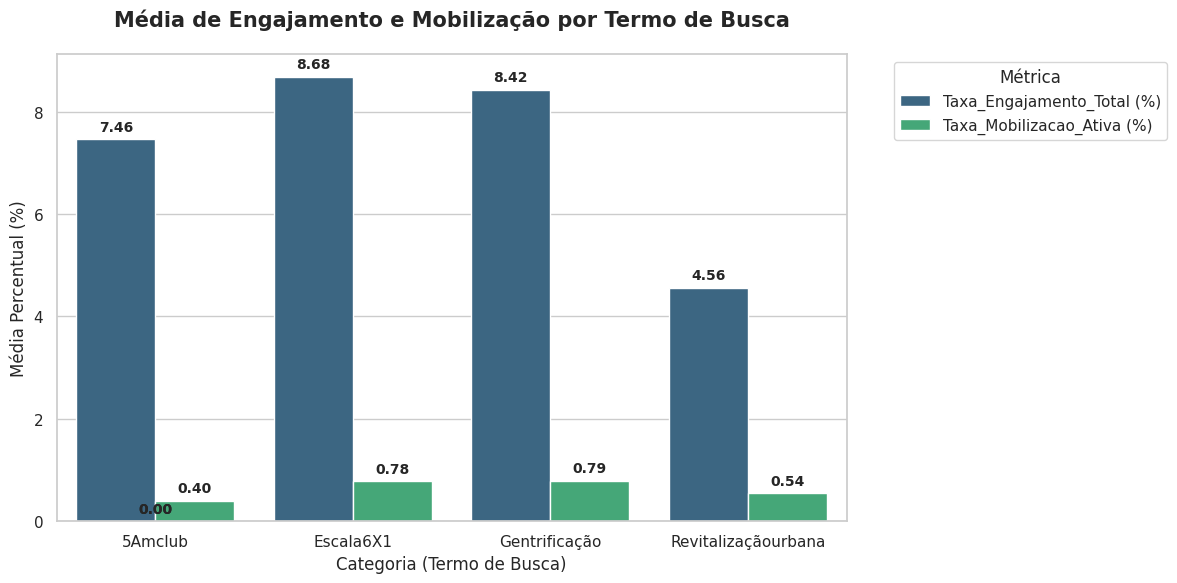

,Termo_de_Busca,Taxa_Engajamento_Total (%),Taxa_Mobilizacao_Ativa (%)
0,5Amclub,7.463122,0.398888
1,Escala6X1,8.684317,0.783270
2,Gentrificação,8.422787,0.788359
3,Revitalizaçãourbana,4.560031,0.544918


In [ ]:
# @title ▶️ Gráfico de Barras (Views x Taxa de Engajamento)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar os dados por 'Termo_de_Busca' e calcular as médias
df_avg = df_final.groupby('Termo_de_Busca')[['Taxa_Engajamento_Total (%)', 'Taxa_Mobilizacao_Ativa (%)']].mean().reset_index()

# 2. Reorganizar os dados para o formato 'long' para facilitar a plotagem com Seaborn
df_plot = df_avg.melt(id_vars='Termo_de_Busca', var_name='Métrica', value_name='Média (%)')

# 3. Configurar o estilo visual
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

# 4. Criar o gráfico de barras
bar_plot = sns.barplot(
    data=df_plot,
    x='Termo_de_Busca',
    y='Média (%)',
    hue='Métrica',
    palette='viridis'
)

# 5. Adicionar títulos e rótulos
plt.title('Média de Engajamento e Mobilização por Termo de Busca', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Categoria (Termo de Busca)', fontsize=12)
plt.ylabel('Média Percentual (%)', fontsize=12)
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionar os valores acima das barras para facilitar a leitura
for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

plt.tight_layout()

# 6. Salvar e exibir
nome_grafico_barras = 'Media_Engajamento_Por_Termo.png'
plt.savefig(nome_grafico_barras, dpi=300, bbox_inches='tight')

print(f'✅ Gráfico de barras salvo como: {nome_grafico_barras}')
plt.show()

# Exibir a tabela com os valores exatos
display(df_avg)

✅ Gráfico de barras salvo como: Media_Views_Curtidas_Por_Termo.png


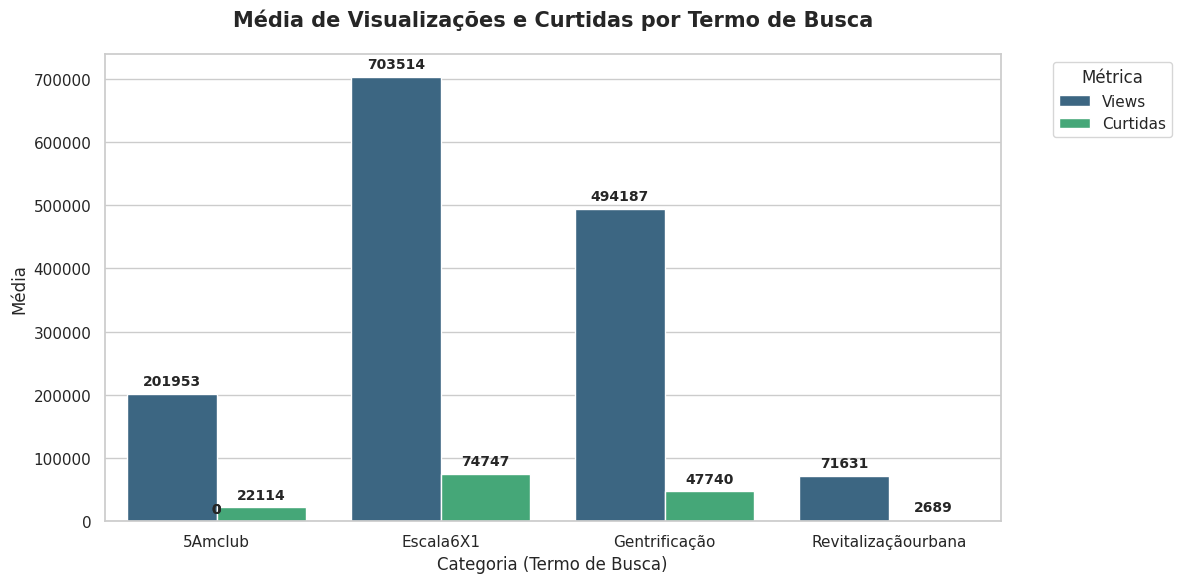

,Termo_de_Busca,Views,Curtidas
0,5Amclub,201952.788732,22113.661972
1,Escala6X1,703513.611511,74747.309353
2,Gentrificação,494187.057143,47740.104762
3,Revitalizaçãourbana,71630.839623,2689.103774


In [ ]:
# @title ▶️ Gráfico de Barras (Views e Curtidas por Termo)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar os dados por 'Termo_de_Busca' e calcular as médias de Views e Curtidas
df_avg_views_curtidas = df_final.groupby('Termo_de_Busca')[['Views', 'Curtidas']].mean().reset_index()

# 2. Reorganizar os dados para o formato 'long' para facilitar a plotagem com Seaborn
df_plot_views_curtidas = df_avg_views_curtidas.melt(id_vars='Termo_de_Busca', var_name='Métrica', value_name='Média')

# 3. Configurar o estilo visual
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

# 4. Criar o gráfico de barras
bar_plot_vc = sns.barplot(
    data=df_plot_views_curtidas,
    x='Termo_de_Busca',
    y='Média',
    hue='Métrica',
    palette='viridis'
)

# 5. Adicionar títulos e rótulos
plt.title('Média de Visualizações e Curtidas por Termo de Busca', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Categoria (Termo de Busca)', fontsize=12)
plt.ylabel('Média', fontsize=12)
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionar os valores acima das barras para facilitar a leitura
for p in bar_plot_vc.patches:
    bar_plot_vc.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

plt.tight_layout()

# 6. Salvar e exibir
nome_grafico_barras_vc = 'Media_Views_Curtidas_Por_Termo.png'
plt.savefig(nome_grafico_barras_vc, dpi=300, bbox_inches='tight')

print(f'✅ Gráfico de barras salvo como: {nome_grafico_barras_vc}')
plt.show()

# Exibir a tabela com os valores exatos
display(df_avg_views_curtidas)

In [ ]:
# @title ▶️ Gerar Gráfico Interativo Views x Engajamento (%)
import plotly.express as px

# Criando o gráfico interativo de Engajamento Total
fig = px.scatter(
    df_final, # Changed df_proc to df_final
    x='Views',
    y='Taxa_Engajamento_Total (%)',
    hover_data=['Autor', 'Data_Hora', 'Link_do_Post'], # Informações ao passar o mouse
    log_x=True, # Escala logarítmica para visualizações
    title='Gráfico Interativo: Views vs Engajamento (Interativo)',
    labels={'Views': 'Visualizações (Log)', 'Taxa_Engajamento_Total (%)': 'Engajamento (%)'},
    template='plotly_white',
    color='Taxa_Engajamento_Total (%)',
    color_continuous_scale='Viridis'
)

# Configuração para abrir o link ao clicar
# Nota: No Plotly interativo do Colab, você pode copiar o link do hover
# ou podemos configurar um evento de clique.
fig.update_traces(marker=dict(size=12, line=dict(width=1, color='Black')))

fig.show()

Sucesso: Utilizando os dados de 'df_final' presentes na memória.
Post com maior mobilização do '5amclub' (index 309) removido para melhorar a escala do gráfico.
Sucesso! O gráfico corrigido foi salvo como 'Comparacao_Mobilizacao_Filtrada.png'.


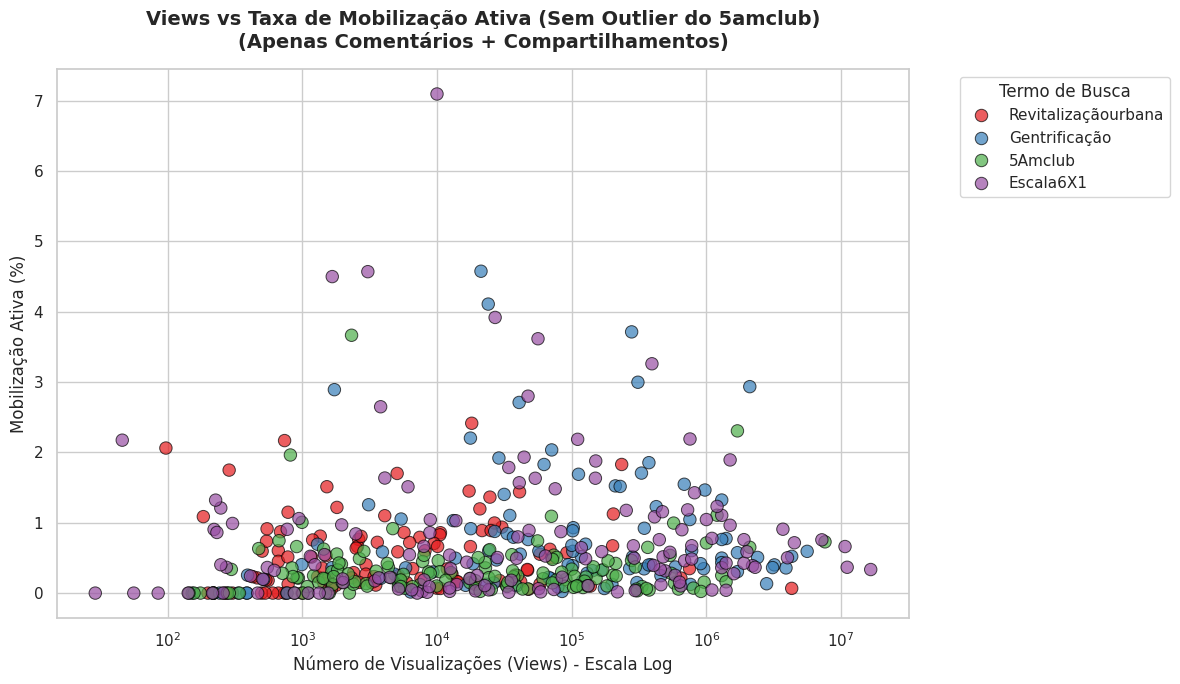

In [ ]:
# @title ▶️ Mapeamento Comparativo Filtrado (Sem Outlier)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

caminho_arquivo = '/content/Mapeamento_Completo_Redes.xlsx'

# Tenta recuperar df_final da memória ou carregar do arquivo
if 'df_final' in locals():
    df_dados = df_final.copy()
    print("Sucesso: Utilizando os dados de 'df_final' presentes na memória.")
elif os.path.exists(caminho_arquivo):
    df_dados = pd.read_excel(caminho_arquivo)
    print("Sucesso: Dados carregados de 'Mapeamento_Completo_Redes.xlsx'.")
else:
    print("❌ ERRO: O arquivo 'Mapeamento_Completo_Redes.xlsx' não foi encontrado.")
    print("👉 Por favor, envie os arquivos .ndjson na barra lateral esquerda e execute o bloco do 'Passo 4: Executar Raspagem de Dados' antes de rodar esta célula.")
    df_dados = None

if df_dados is not None:
    # Normalizar termos de busca para garantir a busca sem problemas de maiúsculas/minúsculas
    df_dados['Termo_de_Busca_Lower'] = df_dados['Termo_de_Busca'].str.lower()

    # Identificar o post do termo '5amclub' com a maior Taxa de Mobilização Ativa
    mask_5am = df_dados['Termo_de_Busca_Lower'] == '5amclub'

    if mask_5am.any():
        idx_max_mobilizacao_5am = df_dados[mask_5am]['Taxa_Mobilizacao_Ativa (%)'].idxmax()
        # Criar o DataFrame sem o outlier
        df_filtrado_grafico = df_dados.drop(index=idx_max_mobilizacao_5am)
        print(f"Post com maior mobilização do '5amclub' (index {idx_max_mobilizacao_5am}) removido para melhorar a escala do gráfico.")
    else:
        df_filtrado_grafico = df_dados.copy()
        print("Aviso: Termo de busca '5amclub' não foi detectado nos dados. Gerando gráfico sem filtros adicionais.")

    # Configuração do gráfico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # Plotando o gráfico sem o outlier
    sns.scatterplot(
        data=df_filtrado_grafico,
        x='Views',
        y='Taxa_Mobilizacao_Ativa (%)',
        hue='Termo_de_Busca',
        palette='Set1',
        alpha=0.7,
        edgecolor='black',
        s=80
    )

    plt.title('Views vs Taxa de Mobilização Ativa (Sem Outlier do 5amclub)\n(Apenas Comentários + Compartilhamentos)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Número de Visualizações (Views) - Escala Log', fontsize=12)
    plt.ylabel('Mobilização Ativa (%)', fontsize=12)
    plt.xscale('log')
    plt.legend(title='Termo de Busca', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()

    nome_grafico_filtrado = 'Comparacao_Mobilizacao_Filtrada.png'
    plt.savefig(nome_grafico_filtrado, dpi=300, bbox_inches='tight')
    print(f"Sucesso! O gráfico corrigido foi salvo como '{nome_grafico_filtrado}'.")
    plt.show()